# **Task 2: Convolutional Neural Network (CNN) Classification**

Task 2 Objectives:

- Designs an innovative CNN architecture tailored to the dataset; justifies design choices with relevant research or empirical evidence.
- Training is well within time budget; employs advanced techniques to effectively address class imbalance and overfitting.
- Evaluates CNN comprehensively using multiple metrics; provides insightful analysis of strengths and weaknesses compared to MLP.



## **Data Exploration**

### Imports

Importante!!!! Trocar de CPU PARA GPU

Tempo de execução -> alterar tipo de tempo de execução -> selecionar T4 GPU e guardar


In [ ]:
# Imports
from google.colab import drive
import sys, os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

import time
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import shutil

import numpy as np
from PIL import Image
from collections import Counter
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import roc_curve, auc
from torchvision import transforms

### Load Dataset and Images

In [ ]:
# Creating the Drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/pokemon_dataset'
LOCAL_BASE = '/content/pokemon_dataset'

if not os.path.exists(LOCAL_BASE):
    print("Copying dataset from Drive to local storage...")
    shutil.copytree(DRIVE_BASE, LOCAL_BASE)
    print("Done!")

BASE = LOCAL_BASE

Mounted at /content/drive
Copying dataset from Drive to local storage...
Done!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [ ]:
sys.path.append(BASE)
import CustomImageDataset as CID

# CNN benefits from stronger augmentation
train_dataset = CID.CustomImageDataset(
    annotations_file=f'{BASE}/train_labels.csv',
    img_dir=f'{BASE}/Train/',
    transform=transforms.Compose([
        transforms.Lambda(lambda x: x.convert('RGB')),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.RandomRotation(15),
        transforms.Normalize(mean=[0.5829, 0.5538, 0.5032],
                             std=[0.2714, 0.2608, 0.2786]),
    ])
)

test_dataset = CID.CustomImageDataset(
    img_dir=f'{BASE}/Test/',
    transform=transforms.Compose([
        transforms.Lambda(lambda x: x.convert('RGB')),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5829, 0.5538, 0.5032],
                             std=[0.2714, 0.2608, 0.2786]),
    ])
)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'\nTrain: {len(train_dataset)} imagens')
print(f'Test  : {len(test_dataset)} imagens')
print(f'Number of unique classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

counts = train_dataset.df['label'].value_counts().sort_index()
total  = len(train_dataset)

class_dist = pd.DataFrame({
    'Label':          counts.index,
    'Count':          counts.values,
    'Percentage(%)':  (counts.values / total * 100).round(2)
}).sort_values(by="Count", ascending=False)

print("Class Distribution Summary:")
print(class_dist.to_string(index=False))

print(f"\nMost common: {counts.idxmax()} ({counts.max()} samples, {(counts.max()/total*100):.2f}%)")
print(f"Least common: {counts.idxmin()} ({counts.min()} samples, {(counts.min()/total*100):.2f}%)")


Train: 3600 imagens
Test  : 900 imagens
Number of unique classes: 9
Classes: ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Class Distribution Summary:
   Label  Count  Percentage(%)
   Water    674          18.72
  Normal    606          16.83
  Poison    467          12.97
    Fire    381          10.58
     Bug    374          10.39
   Grass    299           8.31
Fighting    291           8.08
    Rock    264           7.33
  Ground    244           6.78

Most common: Water (674 samples, 18.72%)
Least common: Ground (244 samples, 6.78%)


In [ ]:
labels = train_dataset.df['label'].tolist()

train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

# Smaller batch for CNN (more GPU memory per sample vs MLP)
train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Treino    : {len(train_subset)} imagens")
print(f"Validação : {len(val_subset)} imagens")

train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
val_labels   = [train_dataset.df.iloc[i]['label'] for i in val_idx]

comparison = pd.DataFrame({
    'Treino':    pd.Series(train_labels).value_counts(normalize=True).round(3) * 100,
    'Validação': pd.Series(val_labels).value_counts(normalize=True).round(3) * 100,
}).sort_values(by='Treino', ascending=False)

print(comparison)

Treino    : 2880 imagens
Validação : 720 imagens
          Treino  Validação
Water       18.7       18.8
Normal      16.8       16.8
Poison      13.0       12.9
Fire        10.6       10.6
Bug         10.4       10.4
Grass        8.3        8.3
Fighting     8.1        8.1
Rock         7.3        7.4
Ground       6.8        6.8


## **Model Development CNN**

### Architecture Rationale

Unlike the MLP (Task 1), which flattens the image and loses all spatial information, a CNN preserves the 2D structure of the image. This is critical for Pokémon images because:

- **Local features** (edges, textures, colors in specific regions) are meaningful for type classification (e.g., Fire-type Pokémon often have red/orange tones with flame shapes).
- **Convolutional layers** share weights across spatial positions which leads to fewer parameters and better generalisation.
- **Pooling layers** introduce translational invariance: the classifier works regardless of where in the image the Pokémon appears.

### Class Weights

We used class weights:

$w_c = \sqrt{\frac{N}{n_c}}$

where $N$ is the total number of training samples and $n_c$ is the number of samples in class $c$.

In [ ]:
train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
train_series = pd.Series(train_labels)
class_counts = train_series.value_counts()

total = len(train_labels)
weights_list = []

for pokeType in train_dataset.classes:
    weight = (total / class_counts[pokeType]) ** 0.5
    weights_list.append(weight)

class_weights = torch.tensor(weights_list, dtype=torch.float32).to(device)

print("Class Weights:")
for cls, w in zip(train_dataset.classes, class_weights):
    print(f"  {cls:<12} count: {class_counts[cls]:>4}  weight: {w:.3f}")

Class Weights:
  Bug          count:  299  weight: 3.104
  Fighting     count:  233  weight: 3.516
  Fire         count:  305  weight: 3.073
  Grass        count:  239  weight: 3.471
  Ground       count:  195  weight: 3.843
  Normal       count:  485  weight: 2.437
  Poison       count:  374  weight: 2.775
  Rock         count:  211  weight: 3.694
  Water        count:  539  weight: 2.312


### CNN Model Definition


**Model Architecture**

- The CNN receives batches of shape (B, 3, 64, 64)

**Convolutional Blocks**

The backbone consists of 3 convolutional blocks following the pattern:

`Conv2d → BatchNorm2d → ReLU → Conv2d → BatchNorm2d → ReLU → MaxPool2d → Dropout2d`

Each block extracts local features via 3×3 filters, normalises activations with BatchNorm2d, halves the spatial resolution with MaxPool2d, and randomly drops entire feature maps with Dropout2d to reduce overfitting. Filter depth increases (32 → 64 → 128) while spatial size decreases (64 → 32 → 16 → 8), building a hierarchy from simple patterns in early layers to complex representations in deeper ones.


### Activation Function & Weight Initialisation

After each convolution, a Rectified Linear Unit (ReLU) activation is applied:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU sets all negative activations to zero and keeps positive ones unchanged. This introduces non-linearity into the network. Without it, stacking multiple layers would be equivalent to a single linear transformation, regardless of depth.

All convolutional and linear layers are initialised using Kaiming Normal initialisation:

$$\text{Var}(w) = \frac{2}{n_{in}}$$

where $n_{in}$ is the number of input units to the layer.

Poor initialisation can cause activations to either explode or vanish at the start of training, making learning unstable or impossible. Kaiming initialisation is specifically designed for ReLU activations, it accounts for the fact that ReLU zeros out half of its inputs on average, and scales the initial weights accordingly to maintain stable activation variance across all layers throughout the forward pass.

In [ ]:
class PokemonCNN(nn.Module):
    """
    Input:  (B, 3, 64, 64)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes: int):
        super().__init__()

        # --- Convolutional Blocks ---
        # Block 1: 64x64 → 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 64 → 32
            nn.Dropout2d(p=0.1),
        )

        # Block 2: 32x32 → 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32 → 16
            nn.Dropout2d(p=0.2),
        )

        # Block 3: 16x16 → 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16 → 8
            nn.Dropout2d(p=0.3),
        )

        # Global Average Pooling
        # Reduces 128 x 8 x 8 → 128 x 1 x 1 → 128 (removes spatial dims)
        # Advantage vs Flatten: drastically fewer params which leads to stronger regularisation
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)      # (B, 32, 32, 32)
        x = self.block2(x)      # (B, 64, 16, 16)
        x = self.block3(x)      # (B, 128, 8, 8)
        x = self.gap(x)         # (B, 128, 1, 1)
        x = x.view(x.size(0), -1)  # (B, 128)
        x = self.classifier(x)  # (B, num_classes)
        return x

In [ ]:
NUM_CLASSES = len(train_dataset.classes)
model = PokemonCNN(NUM_CLASSES).to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()
print(model)

Total parameters    : 323,753
Trainable parameters: 323,753

PokemonCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Re

### Loss, Optimizer, Scheduler

- The loss function uses weights inversely proportional to each class frequency (square root scale), penalising errors on minority classes more heavily. This directly addresses class imbalance without modifying the data.

- Adam adapts the learning rate individually for each parameter, converging faster than SGD on small datasets. "weight_decay=1e-4" applies L2 regularisation, penalising large weights and reducing overfitting.

- The learning rate factor=0.5 when val loss does not improve for 7 consecutive epochs. Allows finer convergence in the later stages of training without manually defining a fixed schedule.

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

### Training Loop

### Training Configuration

- Maximum of 30 epochs.

- If val loss does not improve for 10 consecutive epochs, training terminates early. Prevents overfitting and saves computation time.

- The model is saved whenever validation loss reaches a new minimum. At the end of training, the best checkpoint is loaded rather than the last epoch, ensuring the model with the best generalisation is used for evaluation.

- Tracks train loss, validation loss and accuracy, Macro F1 and learning rate per epoch.

In [ ]:
EPOCHS    = 80
PATIENCE  = 7
CHECKPOINT = f"{BASE}/best_cnn_pokemon.pt"

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}

total_start = time.time()

In [ ]:
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Train
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_subset)

    # Validate
    model.eval()
    val_loss, correct = 0.0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            preds = outputs.argmax(1)
            correct     += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss /= len(val_subset)
    val_acc   = correct / len(val_subset)
    val_f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)

    # Timing + GPU
    epoch_time = time.time() - epoch_start
    gpu_mem = (torch.cuda.memory_allocated(device) / 1e6
               if device.type == "cuda" else 0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Val Acc: {val_acc:.2%}  "
          f"Macro F1: {val_f1:.4f}  "
          f"LR: {current_lr:.2e}  "
          f"Time: {epoch_time:.1f}s  "
          f"GPU: {gpu_mem:.0f}MB")

    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f"Checkpoint saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)")

Epoch [  1/80]  Train Loss: 2.6625  Val Loss: 2.0724  Val Acc: 20.83%  Macro F1: 0.1225  LR: 1.00e-03  Time: 7.6s  GPU: 27MB
Checkpoint saved (val_loss=2.0724)
Epoch [  2/80]  Train Loss: 2.2822  Val Loss: 2.1667  Val Acc: 29.72%  Macro F1: 0.1884  LR: 1.00e-03  Time: 4.5s  GPU: 27MB
Epoch [  3/80]  Train Loss: 2.1170  Val Loss: 1.8420  Val Acc: 34.72%  Macro F1: 0.2543  LR: 1.00e-03  Time: 4.4s  GPU: 27MB
Checkpoint saved (val_loss=1.8420)
Epoch [  4/80]  Train Loss: 2.0111  Val Loss: 1.8023  Val Acc: 32.50%  Macro F1: 0.2324  LR: 1.00e-03  Time: 6.8s  GPU: 27MB
Checkpoint saved (val_loss=1.8023)
Epoch [  5/80]  Train Loss: 1.9747  Val Loss: 1.6330  Val Acc: 40.83%  Macro F1: 0.3194  LR: 1.00e-03  Time: 7.8s  GPU: 27MB
Checkpoint saved (val_loss=1.6330)
Epoch [  6/80]  Train Loss: 1.8777  Val Loss: 1.5274  Val Acc: 46.81%  Macro F1: 0.3880  LR: 1.00e-03  Time: 6.4s  GPU: 27MB
Checkpoint saved (val_loss=1.5274)
Epoch [  7/80]  Train Loss: 1.7816  Val Loss: 1.4732  Val Acc: 49.72%  Macr

## **Evaluation**

### Evaluation on the Validation Set

- The best checkpoint (lowest val loss during training) is loaded before final evaluation, ensuring metrics reflect the model with the best generalisation ability.

- Shows precision, recall and F1-score per class, allowing identification of which Pokémon types are hardest to classify. Particularly useful given the class imbalance present in the dataset.

- The main evaluation was given by:

$$\text{Balanced Accuracy} = \frac{1}{C} \sum_{c=1}^{C} \frac{TP_c}{TP_c + FN_c}$$

$$\text{Macro F1} = \frac{1}{C} \sum_{c=1}^{C} F1_c = \frac{1}{C} \sum_{c=1}^{C} \frac{2 \cdot P_c \cdot R_c}{P_c + R_c}$$

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n Classification Report")
print(classification_report(all_labels, all_preds,
                             target_names=train_dataset.classes))

overall_acc  = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy  : {overall_acc:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")


 Classification Report
              precision    recall  f1-score   support

         Bug       1.00      0.97      0.99        75
    Fighting       1.00      1.00      1.00        58
        Fire       0.97      1.00      0.99        76
       Grass       1.00      0.98      0.99        60
      Ground       1.00      1.00      1.00        49
      Normal       0.98      0.99      0.99       121
      Poison       0.99      1.00      0.99        93
        Rock       1.00      1.00      1.00        53
       Water       0.99      0.99      0.99       135

    accuracy                           0.99       720
   macro avg       0.99      0.99      0.99       720
weighted avg       0.99      0.99      0.99       720

Overall Accuracy  : 0.9917
Balanced Accuracy : 0.9926


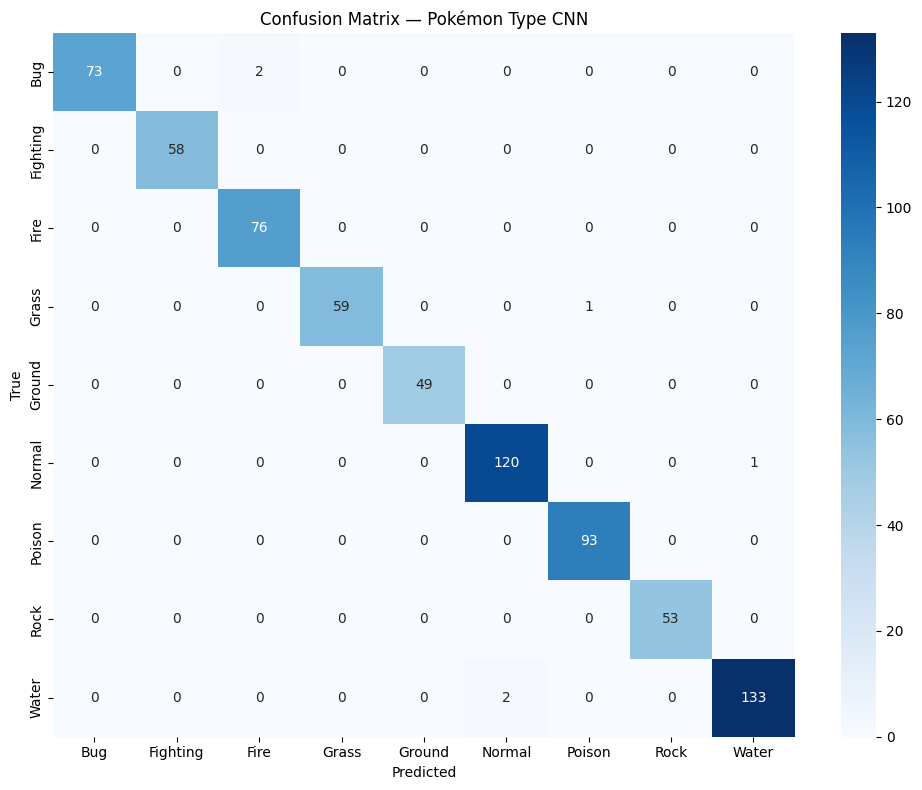

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix — Pokémon Type CNN")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150)
plt.show()

We can see that:

- Rock and Fighting are still the types that have lower accuracy.
- Water, Poison and Fire are still leading the well evaluated types, specially water with almost every prediction corresponding to the true type.

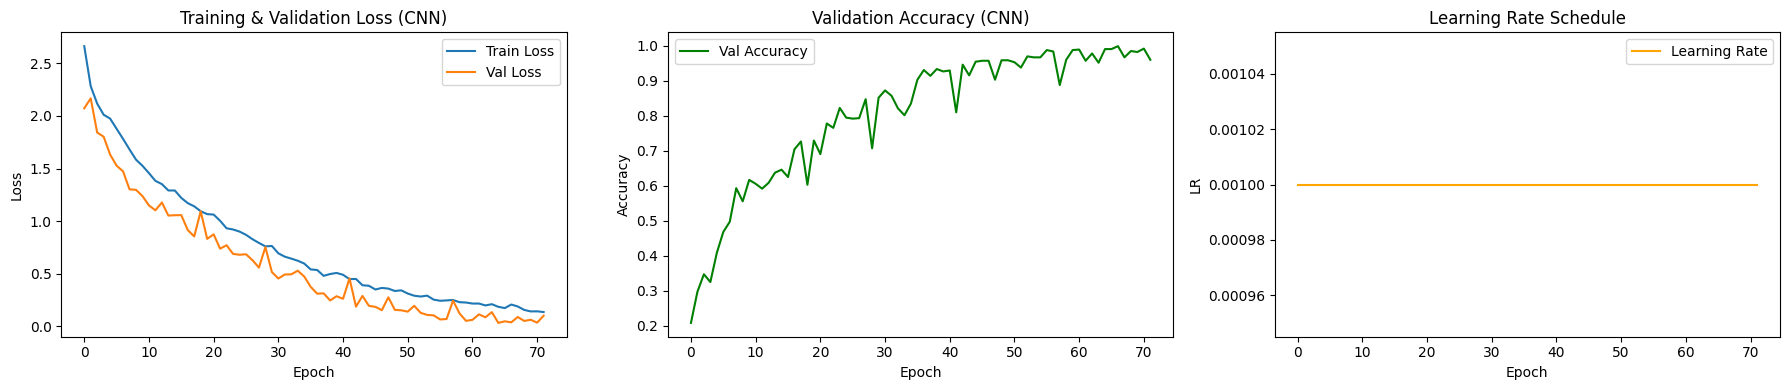

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss (CNN)")
axes[0].legend()

axes[1].plot(history['val_acc'], color='green', label='Val Accuracy')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy (CNN)")
axes[1].legend()

axes[2].plot(history['lr'], color='orange', label='Learning Rate')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].set_title("Learning Rate Schedule")
axes[2].legend()

plt.tight_layout()
plt.savefig("training_curves_cnn.png", dpi=150)
plt.show()

- Training and validation loss are both decreasing with time (epochs). While the training loss is very smooth, the validation loss is a little more unstable (which is completely normal).

- Validation Acc. is going up and the learning rate remains the same in the 30 epochs (because there were no 7 consecutive downgrades in the validation).

- We can conclude that if the epochs were higher, maybe our model would get more F1 and Accuracy, giving us better results.

## **Kaggle Submission**

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()

        for id_, pred in zip(ids, preds):
            predictions.append({
                'Id': id_,
                'label': train_dataset.classes[pred.item()]
            })

# Create submission CSV
submission_df = pd.DataFrame(predictions)
submission_df = submission_df.sort_values('Id')
submission_df.to_csv(f'{BASE}/submission_cnn.csv', index=False)

print(submission_df.head(10))
print(f"\nTotal predictions: {len(submission_df)}")

                                     Id   label
0  003535c4-fa59-4648-b231-30dc139665ed    Fire
1  004a13ae-e627-4df9-8ad0-297449af3b22  Poison
2  00b78c26-7b4f-4582-bbb1-5a1c03f5709e  Normal
3  00bbc4e6-5eb3-4914-b3b6-aeb22349a825  Normal
4  00c3c5a5-e49c-453c-ad53-79cd72c6f896  Ground
5  01540c75-52a9-49ec-960c-8341d09ee294  Poison
6  01b0900d-6ee5-4609-9da9-5ca4765d7be2    Rock
7  01ce5264-37cb-4f47-8da3-23528dcfa90f    Fire
8  027773c9-744b-4498-bcf2-83ab8fc0b227  Normal
9  02a846af-f6ca-4896-92a2-486cc34cd435     Bug

Total predictions: 900
